In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score
)

import warnings
warnings.filterwarnings("ignore")

# Load best model
best_model = joblib.load("../models/best_fraud_model.pkl")

# Load test data
X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").squeeze()

# Load probabilities
y_prob = np.load("../data/processed/best_model_probs.npy")
y_pred = best_model.predict(X_test)

print("Model and test data loaded successfully!")
print("Test Set Shape:", X_test.shape)
print("\nTarget Distribution in Test Set:")
print(y_test.value_counts())

Model and test data loaded successfully!
Test Set Shape: (1272524, 29)

Target Distribution in Test Set:
isFraud
0    1270881
1       1643
Name: count, dtype: int64


In [2]:
print("Detailed Classification Report:")
print("="*60)
print(classification_report(
    y_test,
    y_pred,
    target_names=["Non-Fraud", "Fraud"]
))

Detailed Classification Report:
              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270881
       Fraud       0.99      1.00      0.99      1643

    accuracy                           1.00   1272524
   macro avg       0.99      1.00      1.00   1272524
weighted avg       1.00      1.00      1.00   1272524



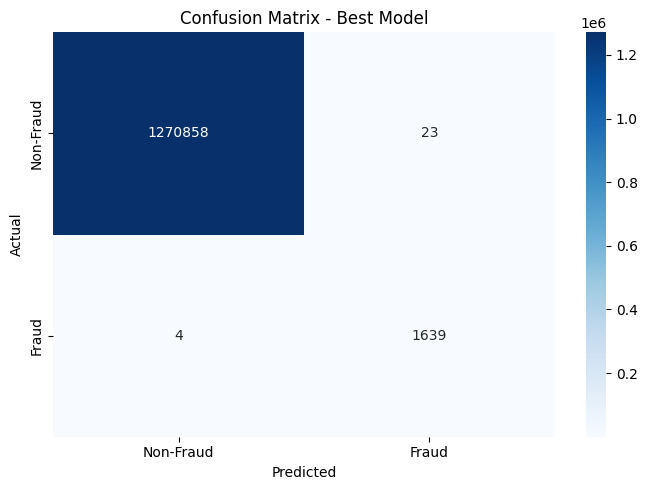


True Negatives  (Correct Non-Fraud): 1270858
False Positives (Non-Fraud predicted as Fraud): 23
False Negatives (Fraud missed by model): 4
True Positives  (Correct Fraud caught): 1639

Fraud Catch Rate (Recall): 99.76%
False Alarm Rate: 0.0%


In [3]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Non-Fraud", "Fraud"],
    yticklabels=["Non-Fraud", "Fraud"]
)
plt.title("Confusion Matrix - Best Model")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.show()

# Detailed breakdown
tn, fp, fn, tp = cm.ravel()
print(f"\nTrue Negatives  (Correct Non-Fraud): {tn}")
print(f"False Positives (Non-Fraud predicted as Fraud): {fp}")
print(f"False Negatives (Fraud missed by model): {fn}")
print(f"True Positives  (Correct Fraud caught): {tp}")
print(f"\nFraud Catch Rate (Recall): {round(tp/(tp+fn)*100, 2)}%")
print(f"False Alarm Rate: {round(fp/(fp+tn)*100, 2)}%")

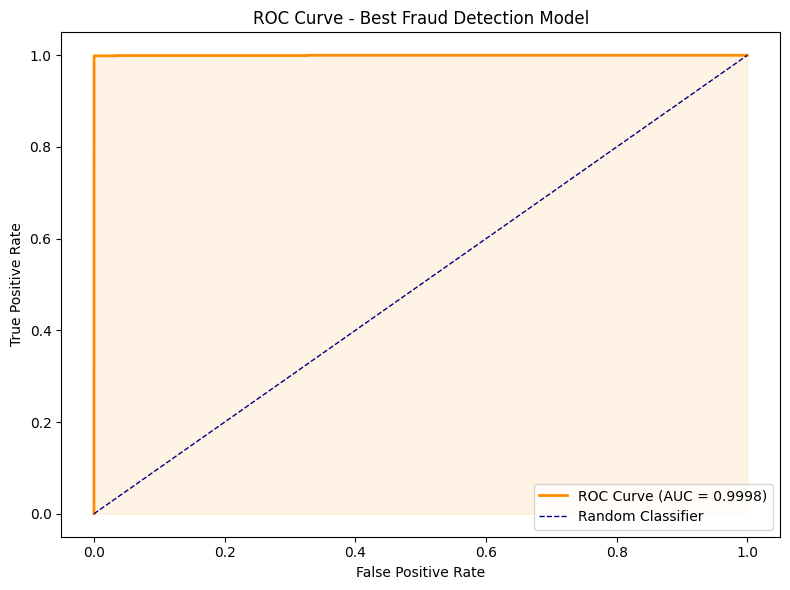

ROC-AUC Score: 0.9998


In [4]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=1, linestyle="--",
         label="Random Classifier")
plt.fill_between(fpr, tpr, alpha=0.1, color="darkorange")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Best Fraud Detection Model")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(f"ROC-AUC Score: {roc_auc:.4f}")

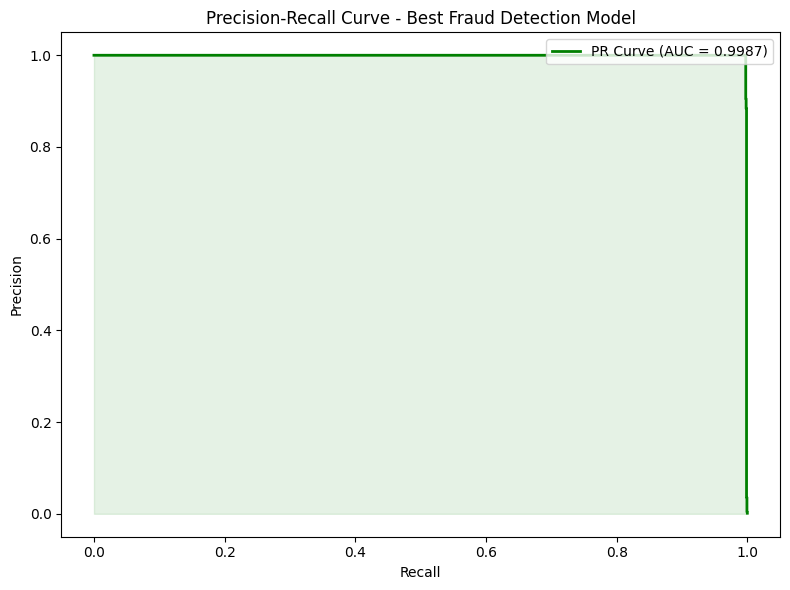

PR-AUC Score: 0.9987


In [5]:
precision, recall, pr_thresholds = precision_recall_curve(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color="green", lw=2,
         label=f"PR Curve (AUC = {pr_auc:.4f})")
plt.fill_between(recall, precision, alpha=0.1, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Best Fraud Detection Model")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

print(f"PR-AUC Score: {pr_auc:.4f}")

In [ ]:
# Default threshold is 0.5
# For fraud detection we may want higher recall
# Let's find the best threshold for F1 score

thresholds_range = np.arange(0.1, 0.9, 0.05)
results = []

for thresh in thresholds_range:
    y_pred_thresh = (y_prob >= thresh).astype(int)
    
    if y_pred_thresh.sum() == 0:
        continue
    
    results.append({
        "threshold": round(thresh, 2),
        "precision": round(precision_score(y_test, y_pred_thresh, zero_division=0), 4),
        "recall": round(recall_score(y_test, y_pred_thresh, zero_division=0), 4),
        "f1": round(f1_score(y_test, y_pred_thresh, zero_division=0), 4)
    })

thresh_df = pd.DataFrame(results)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(thresh_df["threshold"], thresh_df["precision"], label="Precision", marker="o")
plt.plot(thresh_df["threshold"], thresh_df["recall"], label="Recall", marker="o")
plt.plot(thresh_df["threshold"], thresh_df["f1"], label="F1 Score", marker="o")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Tuning - Precision vs Recall vs F1")
plt.legend()
plt.tight_layout()
plt.show()

# Best threshold by F1
best_thresh_row = thresh_df.loc[thresh_df["f1"].idxmax()]
print(f"\nBest Threshold by F1 Score: {best_thresh_row['threshold']}")
print(f"Precision: {best_thresh_row['precision']}")
print(f"Recall: {best_thresh_row['recall']}")
print(f"F1 Score: {best_thresh_row['f1']}")

In [ ]:
best_threshold = best_thresh_row["threshold"]

y_pred_best_thresh = (y_prob >= best_threshold).astype(int)

print(f"Results with Optimized Threshold ({best_threshold}):")
print("="*60)
print(classification_report(
    y_test,
    y_pred_best_thresh,
    target_names=["Non-Fraud", "Fraud"]
))

In [ ]:
# Converting probability to risk score (0-100)
risk_scores = (y_prob * 100).astype(int)

# Plot distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# All transactions
sns.histplot(risk_scores, bins=50, kde=True, ax=axes[0])
axes[0].set_title("Risk Score Distribution - All Transactions")
axes[0].set_xlabel("Risk Score")

# Fraud vs Non-Fraud
fraud_scores = risk_scores[y_test == 1]
non_fraud_scores = risk_scores[y_test == 0]

axes[1].hist(non_fraud_scores, bins=50, alpha=0.6,
             color="steelblue", label="Non-Fraud")
axes[1].hist(fraud_scores, bins=50, alpha=0.6,
             color="tomato", label="Fraud")
axes[1].set_title("Risk Score: Fraud vs Non-Fraud")
axes[1].set_xlabel("Risk Score")
axes[1].legend()

plt.tight_layout()
plt.show()